In [6]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [7]:
def feature_map(x):
    """Encodes classical data points into the 4-qubit quantum state space."""
    qc = QuantumCircuit(N_QUBITS)
    for q in range(N_QUBITS):
        qc.rx((q + 1) * x, q)
    return qc

def quantum_kernel(x, y):
    """Computes the transition amplitude (fidelity) between states x and y."""
    qc = QuantumCircuit(N_QUBITS)
    qc.compose(feature_map(y), inplace=True)
    qc.compose(feature_map(x).inverse(), inplace=True)
    
    psi = Statevector.from_instruction(qc)
    amp0 = psi.data[0]
    return np.abs(amp0)**2
    

# Classical Baseline RBF Kernel
sigma = 0.2
def rbf_kernel(x, y):
    return np.exp(-(x - y)**2 / (2 * sigma**2))


def dkernel_dx(kernel_fn, x, y, eps=1e-5):
    """First derivative with respect to the first positional argument (x)."""
    return (kernel_fn(x + eps, y) - kernel_fn(x - eps, y)) / (2 * eps)

def dkernel_dy(kernel_fn, x, y, eps=1e-5):
    """First derivative with respect to the second positional argument (y)."""
    return (kernel_fn(x, y + eps) - kernel_fn(x, y - eps)) / (2 * eps)

def dkernel_dxdy(kernel_fn, x, y, eps=1e-5):
    """Mixed partial derivative with respect to both arguments."""
    f_p_p = kernel_fn(x + eps, y + eps)
    f_p_m = kernel_fn(x + eps, y - eps)
    f_m_p = kernel_fn(x - eps, y + eps)
    f_m_m = kernel_fn(x - eps, y - eps)
    return (f_p_p - f_p_m - f_m_p + f_m_m) / (4 * eps**2)


# Deterministic Quantum SVR Solver class
class QKSVRSolverODE:
    def __init__(self, x_train, kernel_fn, gamma=1e5):
        """
        Support Vector Regression Solver driven by Quantum Kernels.
        Designed to solve the linear system: df/dx + f(x) = sin(x), f(0) = 0
        """
        self.x_train = np.array(x_train)
        self.kernel_fn = kernel_fn
        self.gamma = gamma  # Regularization parameter
        self.N = len(self.x_train)
        
        # SVR Weight Matrix variables
        self.alpha = None
        self.beta = None
        self.eta = None
        self.b = None

    def fit(self, x0=0.0, f0=0.0):
        """Assembles block operational matrices and extracts weights directly."""
        N = self.N
        X = self.x_train
        
        # 1. Compute foundational derivative block matrices
        Omega_11 = np.zeros((N, N))
        Omega_10 = np.zeros((N, N))
        Omega_01 = np.zeros((N, N))
        Omega_00 = np.zeros((N, N))
        
        for i in range(N):
            for j in range(N):
                Omega_11[i, j] = dkernel_dxdy(self.kernel_fn, X[j], X[i])
                Omega_10[i, j] = dkernel_dx(self.kernel_fn, X[j], X[i])
                Omega_01[i, j] = dkernel_dy(self.kernel_fn, X[j], X[i])
                Omega_00[i, j] = self.kernel_fn(X[j], X[i])
                
        # 2. Construct boundary-state constraint vectors matching point x0
        h_1 = np.array([dkernel_dx(self.kernel_fn, X[i], x0) for i in range(N)])
        h_0 = np.array([self.kernel_fn(X[i], x0) for i in range(N)])
        h_00 = self.kernel_fn(x0, x0)
        
        # Ridge regularizer vector mapping
        I_reg = np.eye(N) / self.gamma
        
        # 3. Build structural row vectors for Matrix A (df/dx + f(x) -> operational coefficient is +1.0)
        # SVR layout identity matrix mappings:
        row1_left = Omega_11 + I_reg + Omega_10 + Omega_01 + Omega_00
        row1_mid = (h_1 + h_0).reshape(-1, 1)
        row1_right = np.ones((N, 1))
        
        row2_left = (h_1 + h_0).reshape(1, -1)
        row2_mid = np.array([[h_00 + (1.0 / self.gamma)]])
        row2_right = np.array([[1.0]])
        
        row3_left = np.ones((1, N))
        row3_mid = np.array([[1.0]])
        row3_right = np.array([[0.0]])
        
        # 4. Vertically stack blocks to initialize matrix system
        A_top = np.hstack((row1_left, row1_mid, row1_right))
        A_mid = np.hstack((row2_left, row2_mid, row2_right))
        A_bot = np.hstack((row3_left, row3_mid, row3_right))
        A = np.vstack((A_top, A_mid, A_bot))
        
        # 5. Build solution target vector B incorporating non-homogeneous sin(x) values
        B = np.zeros(N + 2)
        B[:N] = np.sin(X)
        B[N] = f0
        
        # Linear tracking execution
        weights = np.linalg.solve(A, B)
        
        self.alpha = weights[:N]
        self.beta = weights[N]
        self.b = weights[N + 1]
        self.eta = self.alpha.copy() # In this target linear ODE, mapping eta == alpha holds true

    def predict(self, x_test, x0=0.0):
        """Evaluates prediction output across arbitrary test ranges."""
        predictions = []
        for x in x_test:
            term_alpha = sum(self.alpha[i] * dkernel_dx(self.kernel_fn, self.x_train[i], x) for i in range(self.N))
            term_eta = sum(self.eta[i] * self.kernel_fn(self.x_train[i], x) for i in range(self.N))
            term_beta = self.beta * self.kernel_fn(x0, x)
            
            f_val = term_alpha + term_eta + term_beta + self.b
            predictions.append(f_val)
        return np.array(predictions)


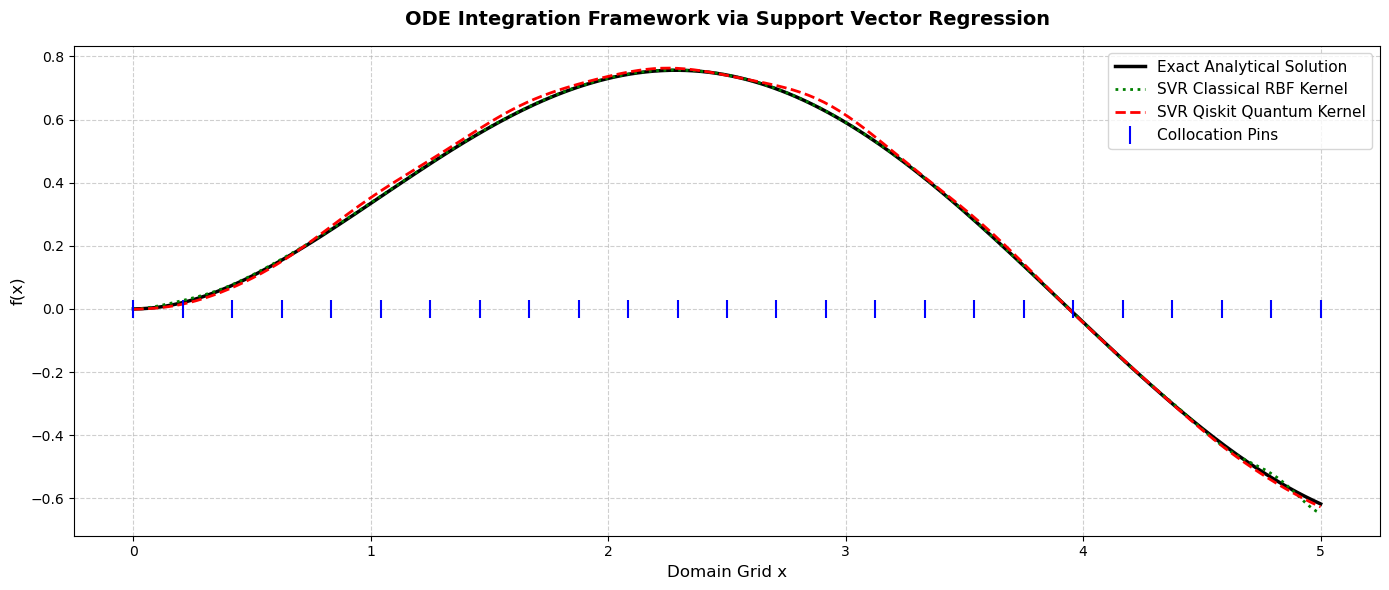

In [8]:
N_QUBITS = 4
x_train = np.linspace(0, 5, 25)
x_test = np.linspace(0, 5, 300)

# Exact Analytical Solution: 0.5 * (sin(x) - cos(x) + exp(-x))
exact = 0.5 * (np.sin(x_test) - np.cos(x_test) + np.exp(-x_test))

# Classical RBF solver
rbf_svr = QKSVRSolverODE(x_train, rbf_kernel, gamma=1e6)
rbf_svr.fit(x0=0.0, f0=0.0)
rbf_pred = rbf_svr.predict(x_test)

# Quantum solver SVR
qk_svr = QKSVRSolverODE(x_train, quantum_kernel, gamma=1e6)
qk_svr.fit(x0=0.0, f0=0.0)
qk_pred = qk_svr.predict(x_test)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.plot(x_test, exact, 'k-', label='Exact Analytical Solution', linewidth=2.5)
ax.plot(x_test, rbf_pred, 'g:', label='SVR Classical RBF Kernel', linewidth=2)
ax.plot(x_test, qk_pred, 'r--', label='SVR Qiskit Quantum Kernel', linewidth=2)

# Collocation pins marking training locations along the baseline
ax.scatter(x_train, np.zeros_like(x_train), color='blue', marker='|', s=150, label='Collocation Pins', zorder=3)

ax.set_title("ODE Integration Framework via Support Vector Regression", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Domain Grid x", fontsize=12)
ax.set_ylabel("f(x)", fontsize=12)
ax.legend(loc="best", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()